In [1]:
import sys
import numpy as np
import matplotlib as mplt
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles, make_classification, make_moons

from tqdm import tqdm
import pandas as pd
import random
import math
import copy
from typing import Annotated, Any, Callable
from pydantic import BaseModel, Field, WithJsonSchema
import pydantic
import numbers
import cv2

from PIL import Image

from numpy.lib.stride_tricks import sliding_window_view
from typing import Any, Callable, Dict, List, Optional, Sequence, Tuple, Union


In [18]:
%load_ext autoreload
%autoreload 2

import sys
for p in ['../../../../src']:
    if p not in sys.path:
        sys.path.append(p)
        
import spikeml as sml
from spikeml.utils.nb_util import xdisplay, Markup
from spikeml.core.signal import signal_dc, signal_pulse, encode1_onehot, encode_onehot, signal_ranges, mean_per_input
from spikeml.core.ngram import build_ngram, ngram_find, ngram_msample, print_ngrams

from spikeml.plot.plot_util import plot_hist, plot_data, plot_lidata, plot_input, plot_xt, plot_mt, plot_spikes, imshow_matrix, imshow_nmatrix
from spikeml.core.params import Params, LayerParams, ConnectorParams, SpikeParams, SSensorParams, SNNParams, SSNNParams

from spikeml.core.params import Params, LayerParams, NNParams, ConnectorParams, SpikeParams, SSensorParams, SNNParams, SSNNParams
from spikeml.ui.ipywidgets_ui import ui
from spikeml.utils.widgets import _tqdm

from spikeml.core.matrix import matrix_split, normalize_matrix, _mult, cmask, cmask2, matrix_init, matrix_init2
from spikeml.core.monitor import Monitor

from spikeml.core.spikes import pspike, spike
from spikeml.core.base import Component, Module, Fan, Composite, Chain
from spikeml.core.layer import Layer, SimpleLayer, LinearLayer, NormalizeLayer, LayerNorm, ThresholdLayer, BinaryThresholdLayer
from spikeml.core.snn import SNN, SSNN, DSSNN
from spikeml.core.sensor import SSensor
from spikeml.core.connector import Connector, LinearConnector, RateConnector, LIConnector, LIConnector2
from spikeml.core.chain import make_snn_chain, make_ssnn_chain, chain_validate

from spikeml.core.feedback import compute_error, xcompute_error, compute_sg, FeedbackAdapter

from spikeml.datasets.dataset import SimpleDataset, DataLoader
from spikeml.datasets.encoder import one_hot
from spikeml.datasets.cv.glyph import Glyph, make_glyphs, show_glyphs, make_glyph, glyph, glyph_dataset, show_all_glyph_txs

from spikeml.core.runner import Context, DataRunner, InferenceRunner, run, nrun, Context, run_with, run_with_feedback


from spikeml.core.sensor_monitor import SSensorMonitor
from spikeml.core.sensor_viewer import SSensorMonitorViewer
from spikeml.core.layer_monitor import LayerMonitor
from spikeml.core.connector_monitor import ConnectorMonitor, LIConnectorMonitor
from spikeml.core.snn_monitor import SNNMonitor, SSNNMonitor
from spikeml.core.layer_viewer import LayerMonitorViewer
from spikeml.core.snn_viewer import SNNMonitorViewer, SSNNMonitorViewer
from spikeml.core.connector_viewer import ConnectorMonitorViewer, LIConnectorMonitorViewer
from spikeml.core.feedback_viewer import ErrorMonitorViewer

from spikeml.core.snn_stats import connector_stats, htest_connections, htest_connector_identity
from spikeml.core.snn_stats_viewer import plot_snn_stats

from spikeml.core.optimize import make_params_spec, vec2dic, setattrs, params_search, set_all_attrs

from spikeml.cv.img_util import show_kmaps, show_tiles, show_kernels, show_kernels_
from spikeml.utils.vector import normalize, normalize_all
from spikeml.utils.img_util import show_img, show_imgs, cv_bgr2rgb, mshow
from  spikeml.core.metrics import eval, print_pred
from spikeml.utils.vector import normalize_all, _sum



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
SEED=37
random.seed(SEED)
np.random.seed(SEED)
np.set_printoptions(edgeitems=3, infstr='inf', linewidth=120, nanstr='nan', precision=4, suppress=True, threshold=1000, formatter=None)


# Datasets

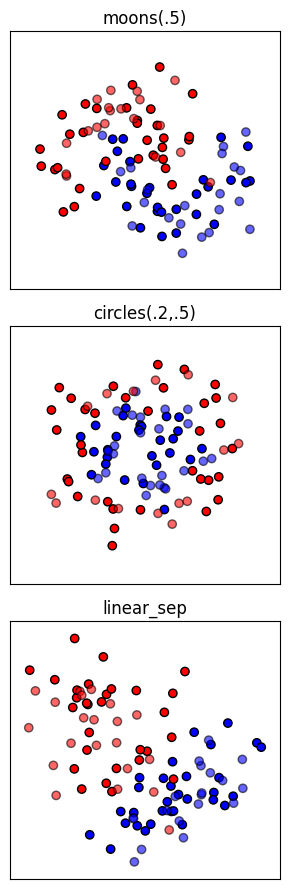

In [7]:
X, y = make_classification(
    n_features=2, n_redundant=0, n_informative=2, random_state=SEED, n_clusters_per_class=1
)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

dataset_names = [
    'moons(.5)',
    'circles(.2,.5)',
    'linear_sep'
]
datasets = [
    make_moons(noise=0.3, random_state=0),
    make_circles(noise=0.2, factor=0.5, random_state=1),
    linearly_separable,
]


names = [
]
classifiers = [
]
#figsize = (27, 9)
figsize = (3*(1+len(classifiers)), 3*len(datasets))
figure = plt.figure(figsize=figsize)
i = 1
# iterate over datasets
for ds_cnt, ds in enumerate(datasets):
    # preprocess dataset, split into training and test part
    X, y = ds
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=42
    )

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # just plot the dataset first
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(["#FF0000", "#0000FF"])
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:
        ax.set_title("Input data")
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
    # Plot the testing points
    ax.scatter(
        X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k"
    )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(dataset_names[i-1])

    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i)

        clf = make_pipeline(StandardScaler())
        clf.fit(X_train, y_train)
        #score = clf.score(X_test, y_test)
        score = 0.0
        #DecisionBoundaryDisplay.from_estimator(
        #    clf, X, cmap=cm, alpha=0.8, ax=ax, eps=0.5
        #)

        # Plot the training points
        ax.scatter(
            X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k"
        )
        # Plot the testing points
        ax.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c=y_test,
            cmap=cm_bright,
            edgecolors="k",
            alpha=0.6,
        )


        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:
            ax.set_title(name)
        ax.text(
            x_max - 0.3,
            y_min + 0.3,
            ("%.2f" % score).lstrip("0"),
            size=15,
            horizontalalignment="right",
        )
        i += 1

plt.tight_layout()
plt.show()

# Neural 

In [ ]:
#ds = datasets[0]
#X, y = ds

X, y = make_classification(n_classes=3,
    n_features=10, n_informative=10, n_redundant=0, random_state=SEED, n_clusters_per_class=1
)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)
print('X:', X.shape, 'X_train:', X_train.shape, 'y_train:', y_train.shape)
labels = np.unique(y).tolist()
print(labels)

X: (100, 10) X_train: (60, 10) y_train: (60,)
[0, 1, 2]


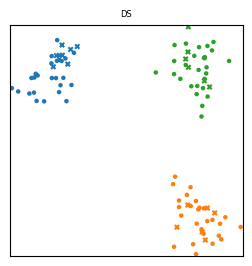

In [76]:
def scatter(X, y,  Xt=None, yt=None, i0=0, i1=1, s=5, stf=2, margin=0.2, ax=None, title=None, figsize=(3, 3), callback=None):
    if Xt is not None:
        x1_min, x1_max = X[:, i0].min() - margin, X[:, i0].max() + margin
        x2_min, x2_max = Xt[:, i0].min() - margin, Xt[:, i1].max() + margin
        y1_min, y1_max = X[:, i1].min() - margin, X[:, i1].max() + margin
        y2_min, y2_max = Xt[:, i1].min() - margin, Xt[:, i1].max() + margin
        x_min = min(x1_min, x2_min)
        x_max = max(x1_max, x2_max)
        y_min = min(y1_min, y2_min)
        y_max = max(y1_max, y2_max)
    else:
        x_min, x_max = X[:, i0].min() - margin, X[:, i0].max() + margin
        y_min, y_max = X[:, i1].min() - margin, X[:, i1].max() + margin


    fig = None
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)
    if title is not None:
        ax.set_title(title, fontsize=6)

    cmap = plt.cm.tab10 #plt.cm.RdBu
    colors = cmap.colors

    colors_ = [colors[y_ % 10] for y_ in y.tolist()]
    ax.scatter(X[:, i0], X[:, i1], color=colors_, s=s) #c=y, cmap=cm
    if Xt is not None:
        if yt is not None:
            colors_ = [colors[y_ % 10] for y_ in yt.tolist()]
            ax.scatter(Xt[:, i0], Xt[:, i1], color=colors_, marker='x', s=s*stf) #c=yt, cmap=cm,
        else:
            ax.scatter(Xt[:, i0], Xt[:, i1], c='r', marker='x', s=s*stf)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    if callback is not None:
        callback(ax, i0, i1)
    if fig is not None:
        plt.show()


def test_scatter():
    X, y = make_classification(n_classes=3,
        n_features=10, n_informative=10, n_redundant=0, random_state=SEED, n_clusters_per_class=1,
        class_sep=8.0, flip_y=0.0,
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=37
    )
    #scatter(X, y, title='DS0')
    scatter(X_train, y_train, X_test, y_test, title='DS')

test_scatter()

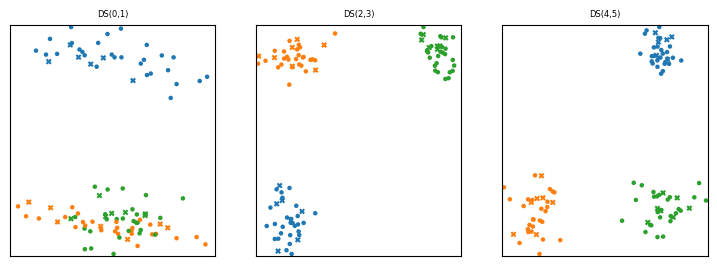

In [75]:
def nscatter(X, y, Xt=None, yt=None, ii=None, title=None, ncols=None, nrows=None, tilesize = 3, s=5, stf=2, margin=0.2, callback=None):
    if ii==None:
        ii = [(0, 1)]
    elif ii=='auto' or ii==True:
        ii = [(i, i+1) for i in range(0,X.shape[1], 2)] 
    n = len(ii)
    if ncols==None:
            if nrows==None:
                ncols = min(20, n)
            else:
                ncols=int(n/nrows) + (n % nrows > 0)
    if nrows==None:
        nrows=n//ncols + int(n% ncols!=0)
        
    figsize=(ncols*tilesize, nrows*tilesize)
    fig, axs = plt.subplots(nrows, ncols, figsize=figsize)
    axs = axs.flatten() if (nrows>1 or ncols>1) else [axs]
    #if title is not None:
    #    fig.suptitle(title)
    for i, (i0, i1) in enumerate(ii):
        _title = (title if title else '') +f'({i0},{i1})'
        scatter(X, y, Xt=Xt, yt=yt, i0=i0, i1=i1, ax=axs[i], title=_title, s=s, stf=stf, margin=margin, callback=callback)
    plt.show()

def test_nscatter():
    X, y = make_classification(n_classes=3,
        n_features=6, n_informative=6, n_redundant=0, random_state=SEED, n_clusters_per_class=1,
        class_sep=8.0, flip_y=0.0,
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=37
    )
    nscatter(X_train, y_train, X_test, y_test, ii=True, title='DS')

test_nscatter()

In [6]:
from scipy.stats import entropy

def entropy1(p, base=None):
    p_ = p[p > 0]
    if base==2:
        entropy = -np.sum(p_ * np.log2(p_))
    else:
        entropy = -np.sum(p_ * np.log(p_))
    return entropy

def fentropy_(yy, bin_size=1, axis=0, keepdims: bool=True, base=2):
    bins = np.arange(yy.min(), yy.max() + bin_size, bin_size)
    counts, _ = np.histogram(yy, bins=bins)
    s = counts.sum()
    p = counts / s if s > 0 else np.zeros_like(counts, dtype=float)
    return entropy(p, axis=axis, keepdims=keepdims, base=base)

def fentropy(yy, bin_size=1, axis=0, keepdims: bool=True, base=2):
    bins = np.arange(yy.min(), yy.max() + bin_size, bin_size)

    def slice_entropy(v):
        counts, _ = np.histogram(v, bins=bins)
        s = counts.sum()
        if s == 0:
            return 0 
        p = counts / s
        return entropy(p, base=base)

    H = np.apply_along_axis(slice_entropy, axis=axis, arr=yy)
    if keepdims:
        H = np.expand_dims(H, axis=axis)        
    return H

        
def ientropy(yy, axis=0, keepdims: bool=True, base=2):
    return entropy(np.bincount(yy)/len(yy), axis=axis, keepdims=keepdims, base=base)

def test_entropy():
    p = np.array([0.5, 0.25, 0.25])
    a = np.array([0, 1, 0, 1, 1, 0, 0, 1])
    b = np.array([0, 0.5, .2, 0, 1, 0.1, 0.2, .3])
    p2 = np.array([[0.5, 0.25, 0.25], [0.1, 0.2, 0.7]])
    a2 = np.array([[0,  1, 0, 1, 1, 0, 0, 1],[0, 1, 0, 1, 0, 1, 0, 1]])
    b2 = np.array([[0, 0.5, .2, 0, 1, 0.1, 0.2, .3], [0.1, 0.2, 0.7, 0.3, 0.4, 0.5, 0.6, 0.7]])

        
    print('H1(p):', entropy1(p, base=2))
    print('H(p):', entropy(p, base=2))
    print('H(a):', ientropy(a, base=2))
    print("H(b):", fentropy(b, bin_size=.1, base=2))
    print('H(p2):', entropy(p2, axis=1, base=2))
    #print('H(a2):', ientropy(a2, axis=1, base=2))
    print("H(b2):", fentropy(b2, axis=1, bin_size=.1, base=2).flatten())
    
    
#test_entropy()


In [10]:
def compute_Hzy(z, y, labels=None, bin_size=.1, base=2):
    Hzy_ = []
    py = []
    if labels is None:
        labels = np.unique(y).tolist()
    for i in range(len(labels)):
        idx = np.where(y == labels[i])[0]
        #print(i, idx)
        py.append(len(idx) / len(y))
        z_ = z[idx, :]
        #print('z_:', z_.shape)
        #print(i, 'z_:', z_)
        hzy = fentropy(z_, axis=0, bin_size=bin_size, base=base).flatten()
        #print(i, 'hzy:', hzy)
        Hzy_.append(hzy)
        #print(f'H(Z|Y={labels[i]}):', hzy)
    py = np.array(py)         # (n_classes,)
    Hzy_ = np.stack(Hzy_, axis=0)
    Hzy = np.sum(py[:, None] * Hzy_, axis=1)
    return Hzy, Hzy_

def compute_Hyz(z, y, labels=None, bin_size=.1, base=2):
    Hyz = []
    if labels is None:
        labels = np.unique(y).tolist()
    bins = np.arange(z.min(), z.max() + bin_size, bin_size)
    bin_ids = np.digitize(z, bins)
    for i in range(len(labels)):
        idx = np.where(y == labels[i])[0]
        #print(i, idx)
        z_ = z[:, idx]
        #print('z_:', z_.shape)
        hyz = fentropy(z_, axis=1, bin_size=bin_size, base=base).flatten()
        #print('hyz:', hyz.shape)
        Hyz.append(hyz)
        #print(f'H(Y|Z={labels[i]}):', hyz)
    Hyz = np.stack(Hyz, axis=0)
    return Hyz

def compute_Hyz(z, y, bin_size=0.1, base=2):
    """
    Compute H(Y | Z_j) for each neuron j.

    z: (k, n)
    y:  (n,)
    """
    k, n = z.shape
    Hyz = np.zeros(k)

    for j in range(k):
        z_ = z[j]
        #print(j, z_)
        bins = np.arange(z_.min(), z_.max() + bin_size, bin_size)
        bin_ids = np.digitize(z_, bins)
        H = 0.0
        #print(j, bins)
        #print(j, bin_ids)
        for b in np.unique(bin_ids):
            idx = np.where(bin_ids == b)[0]
            #print('  j, b, idx:', j, b, idx)
            y_ = y[idx]            
            hy = ientropy(y_, keepdims=False, base=base) # H(Y | Z in this bin)
            pz = len(idx) / n
            H += pz * hy

        Hyz[j] = H

    return Hyz

from sklearn.metrics import mutual_info_score

def mutual_info(z, y, n_bins=20):
    k = z.shape[1]
    mi = np.zeros(k)
    bins = np.linspace(z.min(), z.max(), n_bins)
    for j in range(k):
        z_ = np.digitize(z[:, j], bins)
        mi[j] = mutual_info_score(y, z_)
    return mi

def selectivity(z, y, labels, eps=1e-8):
    a = []
    for y_ in labels:
        #print(y_, y==y_)
        #print('!', z.shape, y.shape)
        #print(y == y_)
        zp = z[y == y_,:]
        zn = z[y != y_,:]
        a.append((zp.mean(axis=0) - zn.mean(axis=0)) / (zp.std(axis=0) + zn.std(axis=0) + eps))
    return np.array(a)

def metrics(z, y, labels=None):
    if labels is None:
        labels = np.unique(y).tolist()
    Hy = ientropy(y)
    print('H(Y):', Hy)
    print('z:', z.shape)
    Hz = fentropy(z, axis=0, bin_size=.1, base=2).flatten()
    print('H(Z):', Hz)
    #print(z)
    #print(y)
    #Hzy,Hzy_ = compute_Hzy(z, y, labels)
    #print('H(Z|Y):', Hzy)
    #print('H(Z|Y=y):', Hzy_)
    #print('I(Z;Y)= Hz - Hzy:', Hz - Hzy)
    print('--')
    #Hyz = compute_Hyz(z, y)
    #print('H(Y|Z):', Hyz)
    #print('I(Y;Z)= Hy - Hyz:', Hy - Hyz)
    #print('--')
    MIyz = mutual_info(z, y, n_bins=20)
    print('I(Y;Z)=MI(Y;Z)', MIyz)
    #MIzy = mutual_info(y[:T], zz, n_bins=20)
    #print('I(Z;Y)=MI(Z;Y)', MIzy)
    print('--')
    sel = selectivity(z, y, labels)
    print('Selectivity:', sel)

def map_selectivity(z, y, labels=None):
    if labels is None:
        labels = np.unique(y).tolist()
    sel = selectivity(z, y, labels)
    sel_map = {}
    for i, label in enumerate(labels):
        imax = np.argmax(sel, axis=0)
        print(imax)
        #sel_map[label] = sel[i]
    return sel_map

def test_metrics():
    X, y = make_classification(n_classes=3,
        n_features=4, n_informative=4, n_redundant=0, random_state=1, n_clusters_per_class=1
    )     
    X_train, X_test, y_train, y_test = train_test_split(
         X, y, test_size=0.4, random_state=42
    )
    labels = np.unique(y).tolist()
    print('labels:', labels)
    print('M:', M.shape)
    print('b:', b.shape)
    print('Z:', Z.shape)
    print('y:', y_train.shape)
    #print('zz:', zz[:5,:])
    #print('Z.min():', Z.min(), 'Z.max():', Z.max())
    T0 = 0
    T1 = Z.shape[0]
    print(T0, T1)
    metrics(Z[T0:T1, :], y_train[T0:T1])
    
#test_metrics()

In [ ]:
def map_scores(scores, labels=None, values=True, min_value=0):
    best_class_idx = np.argmax(scores, axis=0)
    #print(best_class_idx)
    map = {}
    for i, label in enumerate(labels):
        idx = np.where(best_class_idx == i)[0]
        idx_sorted = idx[np.argsort(scores[i, idx])[::-1]] # descending
        if values:
            map[label] = [(j, scores[i, j]) for j in idx_sorted if scores[i, j] > min_value]
        else:
            map[label] =[j for j in idx_sorted if scores[i, j] > min_value]
    return map

def map_scores_split(map):
    map_idx = {}
    map_score = {}
    for label, items in sel_scores.items():
        map_idx[label] = [idx for idx, _ in items]
        map_score[label] = [score for _, score in items]
    return map_idx, map_score

def get_kernel_labels(map, nk=None):
    map_idx = {}
    map_score = {}
    labels = []
    if map is not None:
        nk_ = 0
        for label, items in map.items():
            map_idx[label] = [idx for idx, _ in items]
            if len(map_idx[label])==0:
                continue 
            nk_ = max(nk_, max(map_idx[label])+1)
            map_score[label] = [score for _, score in items]
        nk = nk_ if nk is None else nk
        for k in range(nk):
            b = False
            for label, items in map.items():
                #print('!', k, map_idx[label])
                if k in map_idx[label]:
                    b = True
                    labels.append(label)
                    break
            if not b:
                labels.append(-1)
    return labels

def map_selectivity(z, y, labels=None, values=True, min_value=0):
    if labels is None:
        labels = np.unique(y).tolist()
    sel = selectivity(z, y, labels)
    return sel, map_scores(sel, labels=labels, values=values, min_value=min_value)

def predict_from_map(z, map):
    nc = len(map)
    #print(z)
    zz = np.zeros((nc, z.shape[0], z.shape[1]))
    zz2 = np.zeros((nc, z.shape[0]))
    map_idx, map_score = map_scores_split(map)
    print('map:', map)
    print('map_idx:', map_idx)
    print('map_score:', map_score)
    for i, y in enumerate(map.keys()):
        if len(map_idx[y])==0:
            continue
        print('y:', y, 'map_idx[y]:', map_idx[y])
        z_ = z[:, map_idx[y]]
        print('z:', z)
        print('z_:', z_)
        y_ = np.array(map_idx[y])
        zz[i][:, y_] = z_
        zz2[i] = np.max(zz[i], axis=1)
    print('zz:', zz)
    print('zz2:', zz2)
    best_class_idx = np.argmax(zz2, axis=0)
    return best_class_idx


def confusion_matrix_multiclass(y, y_pred, labels=None):
    if labels is None:
        labels = np.unique(y)

    labels = list(labels)
    L = len(labels)
    cm = np.zeros((L, L), dtype=int)

    for i, yi in enumerate(labels):
        for j, yj in enumerate(labels):
            cm[i, j] = np.sum((y == yi) & (y_pred == yj))

    return cm

def eval(y, y_pred, labels=None, eps=1e-8):
    y = np.asarray(y)
    y_pred = np.asarray(y_pred)

    if labels is None:
        labels = np.unique(y).tolist()

    acc = np.mean(y_pred == y)
    cm = {}
    precisions = []
    recalls = []
    f1s = []

    total_tp = total_fp = total_fn = 0

    for label in labels:
        tp = np.sum((y == label) & (y_pred == label))
        fp = np.sum((y != label) & (y_pred == label))
        fn = np.sum((y == label) & (y_pred != label))
        tn = np.sum((y != label) & (y_pred != label))

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

        total_tp += tp
        total_fp += fp
        total_fn += fn

        cm[label] = {
            'TP': int(tp),
            'FP': int(fp),
            'FN': int(fn),
            'TN': int(tn),
            'precision': precision,
            'recall': recall,
            'f1': f1,
        }


    macro_precision = np.mean(precisions)
    macro_recall = np.mean(recalls)
    macro_f1 = np.mean(f1s)


    micro_precision = total_tp / (total_tp + total_fp + 1e-8)
    micro_recall = total_tp / (total_tp + total_fn + 1e-8)
    micro_f1 = 2 * micro_precision * micro_recall / (
        micro_precision + micro_recall + 1e-8
    )


    return {
        'accuracy': acc,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
        'micro_precision': micro_precision,
        'micro_recall': micro_recall,
        'micro_f1': micro_f1,
        'per_class': cm,
    }
    
       
def print_eval(metrics):
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Macro Precision: {metrics['macro_precision']:.4f}")
    print(f"Macro Recall: {metrics['macro_recall']:.4f}")
    print(f"Macro F1 Score: {metrics['macro_f1']:.4f}")
    print(f"Micro Precision: {metrics['micro_precision']:.4f}")
    print(f"Micro Recall: {metrics['micro_recall']:.4f}")
    print(f"Micro F1 Score: {metrics['micro_f1']:.4f}")
    print("Per Class Metrics:")
    for label, cm in metrics['per_class'].items():
        print(f"  Class {label}: TP={cm['TP']} FP={cm['FP']} FN={cm['FN']} TN={cm['TN']} P={cm['precision']:.4f} R={cm['recall']:.4f} F1={cm['f1']:.4f}")
    
def test_eval():
    sel, sel_scores = map_selectivity(Z_, y_train, values=True)
    print('Selectivity:', sel)
    print('Selectivity Scores:', sel_scores)
    klabels = get_kernel_labels(sel_scores, Z_.shape[1])
    print('Kernel Labels:', klabels)

    print(X_train.shape, y_train.shape)
    print('Z_:', Z_.shape, 'Zt:', Zt.shape)
    #y_train_pred = predict_from_map(Z,sel_scores)
    #print('y_train_pred:', y_train_pred)
    y_test_pred = predict_from_map(Zt[0:10], sel_scores)
    print('y_test_pred:', y_test_pred)
    metrics_train = eval(y_train, y_train_pred)
    metrics_test = eval(y_test, y_test_pred)
    print('Train Metrics:', '-'*20)
    print_eval(metrics_train)
    print('Test Metrics:', '-'*20)
    print_eval(metrics_test)
    
#test_eval()


Selectivity: [[ 0.0000e+00 -8.8192e-01  0.0000e+00  0.0000e+00 -1.1339e+00  1.0000e+08]
 [ 0.0000e+00  1.0000e+08  0.0000e+00  0.0000e+00 -1.0607e+00 -9.4281e-01]
 [ 0.0000e+00 -9.3541e-01  0.0000e+00  0.0000e+00  1.0000e+08 -1.0690e+00]]
Selectivity Scores: {0: [(5, 100000000.0)], 1: [(1, 100000000.0)], 2: [(4, 100000000.0)]}
Kernel Labels: [-1, 1, -1, -1, 2, 0]
(48, 2) (48,)
Z_: (48, 6) Zt: (12, 6)
map: {0: [(5, 100000000.0)], 1: [(1, 100000000.0)], 2: [(4, 100000000.0)]}
map_idx: {0: [5], 1: [1], 2: [4]}
map_score: {0: [100000000.0], 1: [100000000.0], 2: [100000000.0]}
y: 0 map_idx[y]: [5]
z: [[0.     0.     0.     0.     0.     0.1783]
 [0.     0.     0.     0.     0.     0.1818]
 [0.     0.4537 0.     0.     0.     0.    ]
 [0.     0.4506 0.     0.     0.     0.    ]
 [0.     0.4481 0.     0.     0.     0.    ]
 [0.     0.4496 0.     0.     0.     0.    ]
 [0.     0.4449 0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.287  0.    ]
 [0.     0.     0.     0.     0.2418 

ValueError: operands could not be broadcast together with shapes (10,) (12,) 

In [167]:
print(get_kernel_labels(sel_scores, Z.shape[1]))
#print(Zt)
map_idx, map_score = map_scores_split(map)
idxs = [i for kl in map_idx.values() for i in kl]
print('map_idx:', map_idx)
print('idxs:', idxs)
print(M[idxs])
print(Zt)
print(Zt[:,idxs])
predict_from_map(Zt, sel_scores)
#predict_from_map(M[idxs], sel_scores)

[2, -1, -1, 0, 0, 1]
map_idx: {0: [3, 4], 1: [5], 2: [0]}
idxs: [3, 4, 5, 0]
[[ 0.0486  0.0722]
 [-0.0726  0.1483]
 [ 0.1856  0.0983]
 [ 0.0764 -0.0587]]
[[0.5907 0.     0.     0.     0.     0.4435]
 [0.5897 0.     0.     0.     0.     0.4527]
 [0.3855 0.     0.     0.     0.571  0.    ]
 [0.3915 0.     0.     0.     0.5602 0.    ]
 [0.4797 0.     0.     0.     0.326  0.    ]
 [0.6134 0.     0.     0.     0.     0.4445]]
[[0.     0.     0.4435 0.5907]
 [0.     0.     0.4527 0.5897]
 [0.     0.571  0.     0.3855]
 [0.     0.5602 0.     0.3915]
 [0.     0.326  0.     0.4797]
 [0.     0.     0.4445 0.6134]]
map: {0: [(3, 1.6271722602341756), (4, 0.5234224170357914)], 1: [(5, 2.200161396011766)], 2: [(0, 0.4234369895681798)]}
map_idx: {0: [3, 4], 1: [5], 2: [0]}
map_score: {0: [1.6271722602341756, 0.5234224170357914], 1: [2.200161396011766], 2: [0.4234369895681798]}
y: 0 map_idx[y]: [3, 4]
z: [[0.5907 0.     0.     0.     0.     0.4435]
 [0.5897 0.     0.     0.     0.     0.4527]
 [0.3855

array([2, 2, 0, 0, 2, 2], dtype=int64)

{0: [(3, 1.6271722602341756), (4, 0.5234224170357914)], 1: [(5, 2.200161396011766)], 2: [(0, 0.4234369895681798)]}
[2, -1, -1, 0, 0, 1]
[2, -1, -1, 0, 0, 1]


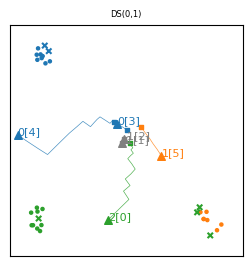

In [166]:

        
def plot_kernels(M__, nk, X, y, Xt=None, yt=None, ii=None, map=None, title=None, ncols=None, nrows=None, tilesize = 3,):
    M__ = np.stack(M__, axis=0)
    
    klabels = get_kernel_labels(map, nk)
    print(klabels)
    cmap = plt.cm.tab10 #plt.cm.RdBu
    colors = cmap.colors
    def _lines(ax, i0, i1):
        for k in range(nk):
            x_ = M__[:, k, i0]
            y_ = M__[:, k, i1]
            label = klabels[k] if klabels is not None else None
            color = None
            if label is not None:
                color = colors[label % len(colors)] if label>=0 else 'gray'
            #print(f'k={k}, label={label}, color={color}')
            ax.plot(x_, y_, linewidth=.5, alpha=.8, color=color)
            colors_ = [colors[y_ % 10] for y_ in y.tolist()]
            ax.scatter(x_[0], y_[0], color=color, marker="s", s=5)
            ax.scatter(x_[-1], y_[-1], color=color, marker="^", s=3*10) #, edgecolors="k"
            ax.text(x_[-1], y_[-1], f'{label}[{k}]', fontsize=8, color=color)
            
    nscatter(X, y, Xt=Xt, yt=yt, ii=True, title='DS', stf=3, callback=_lines)

#plot_kernels(M__, X, y, X_test, y_test, ii=True, title='DS')
print(sel_scores)
print(get_kernel_labels(sel_scores, M.shape[0]))
plot_kernels(M__, M.shape[0], X_train, y_train, X_test, y_test_pred, ii=True, map=sel_scores, title='DS')



X: (60, 2) X_train: (48, 2) y_train: (48,) X_test: (12, 2) y_test: (12,)
X[:5]: [[ 0.886  -0.7529]
 [-0.7976  0.8175]
 [-0.8016 -0.8779]
 [-0.8246  0.8478]
 [-0.6934 -0.7295]]
y[:5]: [1 0 2 0 2]
[0, 1, 2]


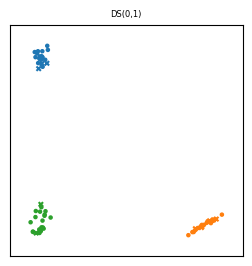

In [168]:
NC=6
NF=6
NC=3
NF=2
N=NC*20
X, y = make_classification(n_samples=N, n_classes=NC,
        n_features=NF, n_informative=NF, n_redundant=0, random_state=SEED, n_clusters_per_class=1,
        class_sep=8.0, flip_y=0.0, scale=.1
    )
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print('X:', X.shape, 'X_train:', X_train.shape, 'y_train:', y_train.shape, 'X_test:', X_test.shape, 'y_test:', y_test.shape)
print('X[:5]:', X[:5])
print('y[:5]:', y[:5])
labels = np.unique(y).tolist()
print(labels)
nscatter(X_train, y_train, X_test, y_test, ii=True,title='DS')

In [169]:
def topk(y, k=2, batch=False):
    if k <= 0:
        return y
    if not batch:
        if len(y.shape)==1:
            idx = np.argpartition(y, -k)[-k:]
            #print('idx:', idx)
            mask = np.zeros_like(y, dtype=bool)
            mask[idx] = True
            y = np.where(mask, y, 0)
        else:             
            y_ = y.reshape(y.shape[0], -1)
            idx = np.argpartition(y_, -k, axis=0)[-k:, :]
            #print('idx:', idx.shape)
            #print('idx:', idx)
            mask = np.zeros_like(y_, dtype=bool)
            mask[idx, np.arange(y_.shape[1])] = True
            #print(mask)
            y_ = np.where(mask, y_, 0)
            y = y_.reshape(y.shape)
        return y
    else:
        if len(y.shape)==2:
            idx = np.argpartition(y, -k, axis=1)[:, -k:]
            #print('idx:', idx.shape)
            #print('idx:', idx)
            mask = np.zeros_like(y, dtype=bool)
            n = np.arange(y.shape[0])[:, None]          # [N,1]
            mask[n, idx] = True
            #print(mask)
            y = np.where(mask, y, 0)
            return y
        else:
            # y: (N, K, D) || (N, K, W, H) 
            y_ = y.reshape(y.shape[0], y.shape[1], -1)
            idx = np.argpartition(y_, -k, axis=1)[:, -k:, :]   # [N, k, D] ; indices of top-k along K (axis=1)
            #print('idx:', idx.shape)
            #print('idx:', idx)
            mask = np.zeros_like(y_, dtype=bool)
            n = np.arange(y_.shape[0])[:, None, None]          # [N,1,1]
            d = np.arange(y_.shape[2])[None, None, :]          # [1,1,D]
            mask[n, idx, d] = True
            #print(mask)
            y_ = np.where(mask, y_, 0)
            y = y_.reshape(y.shape)
            return y
    
def test_topk_flat():
    print('test_topk_flat:')
    a = np.array([0.1, 0.5, 0.3, 0.6])
    print('a:', a)
    a_ = topk(a, 2, False)
    print('a_:', a_)

def test_topk_flat_batch():
    print('test_topk_flat_batch:')
    a = np.array([[0.1, 0.5, 0.3, 0.6], [0.2, 0.4, 0.6, 0.8]])
    print('a:', a)
    a_ = topk(a, 2, True)
    print('a_:', a_)

#print('M:', M.shape)
#print('M:', M)
test_topk_flat()
test_topk_flat_batch()




test_topk_flat:
a: [0.1 0.5 0.3 0.6]
a_: [0.  0.5 0.  0.6]
test_topk_flat_batch:
a: [[0.1 0.5 0.3 0.6]
 [0.2 0.4 0.6 0.8]]
a_: [[0.  0.5 0.  0.6]
 [0.  0.  0.6 0.8]]


NNParams:t_b=20,t_bn=30,e_b=2,g=1,e_err=5,vmin=-1.0,vmax=1.0,topk=1,norm=0,scale=1
ConnectorParams:g=1,e_err=5,vmin=-1.0,vmax=1.0,k_p=2,k_n=2,t_cp=10,t_cn=10,t_p=10.0,t_d=50.0,c_in=0,c_out=0,cmin=-2,cmax=2,mean=0,sd=0.1
M: (6, 2)
X: (60, 2) X_train: (48, 2) y_train: (48,) X_test: (12, 2) y_test: (12,)
Z: (144, 6) Zt: (12, 6)
Z_: (48, 6)
Selectivity: [[ 0.0000e+00 -8.4112e-01  0.0000e+00  0.0000e+00 -1.1339e+00  1.0000e+08]
 [ 0.0000e+00  4.2302e+00  0.0000e+00  0.0000e+00 -1.0607e+00 -9.4281e-01]
 [ 0.0000e+00 -8.8995e-01  0.0000e+00  0.0000e+00  1.0000e+08 -1.0690e+00]]
Selectivity Scores: {0: [(5, 100000000.0)], 1: [(1, 4.23021663683664)], 2: [(4, 100000000.0)]}
Kernel Labels: [-1, 1, -1, -1, 2, 0]
Zt: [[0.0447 0.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     0.0442]
 [0.     0.     0.     0.     0.1518 0.    ]
 [0.     0.     0.     0.     0.1603 0.    ]
 [0.     0.     0.     0.     0.1307 0.    ]
 [0.     0.     0.     0.     0.1271 0.    ]
 [0.     0.     

,X0,X1,"Z[0],-1","Z[1],1","Z[2],-1","Z[3],-1","Z[4],2","Z[5],0",target,pred
0,-0.729460,0.752133,0.044662,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
1,-0.777985,0.749841,0.000000,0.0,0.0,0.0,0.000000,0.044210,0.0,0.0
2,0.775583,-0.816389,0.000000,0.0,0.0,0.0,0.151842,0.000000,1.0,2.0
3,0.711073,-0.836975,0.000000,0.0,0.0,0.0,0.160279,0.000000,1.0,2.0
4,0.885988,-0.752908,0.000000,0.0,0.0,0.0,0.130677,0.000000,1.0,2.0
5,0.913862,-0.744230,0.000000,0.0,0.0,0.0,0.127084,0.000000,1.0,2.0
6,0.849082,-0.760993,0.000000,0.0,0.0,0.0,0.134625,0.000000,1.0,2.0
7,-0.833451,-0.878107,0.000000,0.0,0.0,0.0,0.254732,0.000000,2.0,2.0
8,-0.788135,-0.603054,0.000000,0.0,0.0,0.0,0.186767,0.000000,2.0,2.0
9,0.769034,-0.825948,0.000000,0.0,0.0,0.0,0.154476,0.000000,1.0,2.0


M: [[ 0.0404  0.0986]
 [ 0.0668  0.0026]
 [-0.0007  0.0338]
 [ 0.0091 -0.0131]
 [-0.0548 -0.2381]
 [-0.076  -0.0199]]
Test Metrics: --------------------
Accuracy: 0.5000
Macro Precision: 0.4167
Macro Recall: 0.6667
Macro F1 Score: 0.4667
Micro Precision: 0.5000
Micro Recall: 0.5000
Micro F1 Score: 0.5000
Per Class Metrics:
  Class 0: TP=4 FP=0 FN=0 TN=8 P=1.0000 R=1.0000 F1=1.0000
  Class 1: TP=0 FP=0 FN=6 TN=6 P=0.0000 R=0.0000 F1=0.0000
  Class 2: TP=2 FP=6 FN=0 TN=4 P=0.2500 R=1.0000 F1=0.4000
[-1, 1, -1, -1, 2, 0]


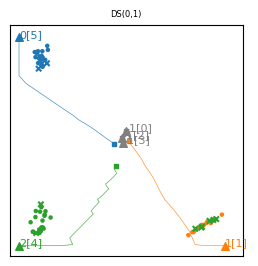

In [218]:
def init(X, labels, Kf=4, params=None, cparams=None, debug=False):
    D = X[0].size
    K1 = len(labels)*Kf
    params = NNParams(vmax=1, vmin=-1) if params is None else params
    cparams = ConnectorParams(vmax=1, vmin=-1, t_p=10, t_d=50) if cparams is None else cparams
    M = matrix_init(size=(K1, D), params=cparams)
    b = np.zeros(K1)
    if debug:
        print(params.fmt())
        print(cparams.fmt())
        print('M:', M.shape)
    return M, b

def propagate(xx, M, b, train=True, epochs=1, log_step = 0, params=None, cparams=None, debug=False):
    _M = M.copy()
    zz = []
    #T = min(100,xx.shape[0])
    M__ = [] 
    #xdisplay(Markup('M', M))
    #print('b:', b)
    z_ = np.zeros(b.shape)
    T = xx.shape[0]*epochs
    for epoch in range(epochs):
        for i in range(0,xx.shape[0]):
            x = xx[i]
            z = M @ x
            #print('_z:', z)
            #z -= b
            z_[:] = z
            z = np.clip(z, params.vmin, params.vmax)
            z = topk(z, params.topk, False)
            zz.append(z)
            if train:
                #update b
                db = z_ - z
                #print('db:', db)
                b += db*.5
                #print('b:', b)
                #update M
                dMp = dMn = None
                if cparams.t_p>0:
                    zp = np.outer(z, x)
                    dMp = (1/cparams.t_p)*zp
                if cparams.t_d>0: 
                    zn = np.outer(z, cparams.vmax-x)
                    dMn = -(1/cparams.t_d)*zn
                _dM = _sum(dMp, dMn)
                _M[:] = M
                M += _dM
                M = np.clip(M, cparams.vmin, cparams.vmax)
                if train:
                    M__.append(M.copy())
                dM = M - _M
            _log = (log_step > 0 and (i % log_step == 0 or (T<0 or (T>=0 and i==T - 1)))) or (log_step == 0 and T > 0 and (i == 0 or i == T - 1))
            if _log:
                print('epoch:', epoch, 'i:', i)
                print('y:', yy[i])
                print('x:', x)
                print('z:', z)
                if train:
                    xdisplay(Markup('M', M), Markup('dM', dM), Markup('_dM', _dM), Markup('dMp', dMp), Markup('dMn', dMn))

    zz = np.stack(zz, axis=0)
    return (zz, M__) if train else zz

params = NNParams(vmax=1, vmin=-1, topk=1)
cparams = ConnectorParams(vmax=1, vmin=-1, t_p=10, t_d=50)
M, b = init(X_train, labels, Kf=2, params=params, cparams=cparams, debug=True)
Z, M__ = propagate(X_train, M, b, train=True, epochs=3, log_step = -1, params=params, cparams=cparams)
Zt = propagate(X_test, M, b, train=False, log_step = -1, params=params, cparams=cparams)
print('X:', X.shape, 'X_train:', X_train.shape, 'y_train:', y_train.shape, 'X_test:', X_test.shape, 'y_test:', y_test.shape)
print('Z:', Z.shape, 'Zt:', Zt.shape)
Z_ = Z[Z.shape[0]-y_train.shape[0]:Z.shape[0],:]
print('Z_:', Z_.shape)
sel, sel_scores= map_selectivity(Z_, y_train, values=True)
print('Selectivity:', sel)
print('Selectivity Scores:', sel_scores)
klabels = get_kernel_labels(sel_scores, M.shape[0])
print('Kernel Labels:', klabels)
print('Zt:', Zt)

y_train_pred = predict_from_map(Z_,sel_scores)
y_test_pred = predict_from_map(Zt, sel_scores)
#print('y_train_pred:', y_train_pred)
print('y_test_pred:', y_test_pred)

df = pd.DataFrame(np.concatenate([X_test, Zt, y_test.reshape(-1, 1), y_test_pred.reshape(-1, 1)], axis=1),
                columns=[f'X{i}' for i in range(X_test.shape[1])] 
                + [f'Z[{i}],{klabels[i]}' for i in range(Zt.shape[1])] + ['target', 'pred'])
display(df)

print('M:', M)
#metrics_train = eval(y_train, y_train_pred[0:y_train.shape[0]])
metrics_test = eval(y_test, y_test_pred)
#print('Train Metrics:', '-'*20)
#print_eval(metrics_train)
print('Test Metrics:', '-'*20)
print_eval(metrics_test)
#plot_kernels(M__, M.shape[0], X_train, y_train, X_test, y_test, ii=True, title='DS')
plot_kernels(M__, M.shape[0], X_train, y_train, X_test, y_test_pred, ii=True,  map=sel_scores, title='DS')


In [221]:
print('b:', b)
print(y_test_pred != y_test)
X_failed = X_test[y_test_pred != y_test]
print('X_failed:', X_failed)
print(M)
for i in range(X_test.shape[0]):
    x = X_test[i]
    z = M @ x
    print(i, 'x:', x, ' -> z:', z)
    #z -= b
    print('  -> z:', z)
    z = np.clip(z, params.vmin, params.vmax)
    print('  -> z:', z)
    z = topk(z, params.topk, False)
    print('  -> z:', z)


b: [ -2.7035  -8.848   -0.5918   0.0199   9.9457 -10.5204]
[False False  True  True  True  True  True False False  True False False]
X_failed: [[ 0.7756 -0.8164]
 [ 0.7111 -0.837 ]
 [ 0.886  -0.7529]
 [ 0.9139 -0.7442]
 [ 0.8491 -0.761 ]
 [ 0.769  -0.8259]]
[[ 0.0404  0.0986]
 [ 0.0668  0.0026]
 [-0.0007  0.0338]
 [ 0.0091 -0.0131]
 [-0.0548 -0.2381]
 [-0.076  -0.0199]]
0 x: [-0.7295  0.7521]  -> z: [ 0.0447 -0.0468  0.0259 -0.0165 -0.1391  0.0405]
  -> z: [ 0.0447 -0.0468  0.0259 -0.0165 -0.1391  0.0405]
  -> z: [ 0.0447 -0.0468  0.0259 -0.0165 -0.1391  0.0405]
  -> z: [0.0447 0.     0.     0.     0.     0.    ]
1 x: [-0.778   0.7498]  -> z: [ 0.0425 -0.0501  0.0259 -0.0169 -0.1359  0.0442]
  -> z: [ 0.0425 -0.0501  0.0259 -0.0169 -0.1359  0.0442]
  -> z: [ 0.0425 -0.0501  0.0259 -0.0169 -0.1359  0.0442]
  -> z: [0.     0.     0.     0.     0.     0.0442]
2 x: [ 0.7756 -0.8164]  -> z: [-0.0491  0.0497 -0.0282  0.0178  0.1518 -0.0427]
  -> z: [-0.0491  0.0497 -0.0282  0.0178  0.1518 -0

In [ ]:
xx,yy = X_train, y_train
xx_ = xx.reshape(xx.shape[0], -1)
labels = np.unique(yy).tolist()
dataset = SimpleDataset(xx, yy)
loader = DataLoader(dataset, batch_size=-1, shuffle=False, num_workers=0, pin_memory=False, seed=SEED)

def make_nn(xx, K1):
    nl1 = NormalizeLayer(scale=3, name='nl1')
    M1 = RateConnector((K1, xx[0].size), params=ConnectorParams(mean=0, sd=.001, t_p=1, t_d=1, cmin=-3, cmax=3))
    ll1 = LinearLayer(M1, params=NNParams(), name='ll1')
    #print(M1.params.fmt())
    #print(ll1.params.fmt())
    nn = Chain([nl1, ll1])
    return nn

K1 = len(labels)*4
nn = make_nn(xx, K1)

def _callback(_, ref, x, y, context):
    print(f'll_2: {context.epoch}/{context.epochs}: {context.t} : {str(x)} -> {str(y)}')    
    ll_2.log()
    title = f'll_2: {context.epoch}/{context.epochs}: {context.t} {str(y)}'
    #show_kernels(ll_1.M.M, xx[0].shape)
    #show_img(ll_2.M.M, title=title)
    
runner = DataRunner(nn, loader, epochs=1, plot=False, log_step=-1, log_epoch=-1, callback=None)#_callback)
result = runner.run(options={'log.modules': False, 'log.connector': False})
print(result)
xdisplay(nn['ll1'].M.M)


{'ref': <spikeml.core.base.Chain object at 0x000001BEAAA8BC70>, 'context': <spikeml.core.runner.Context object at 0x000001BEAAA8A320>}


3,-3
3,-3
3,-3
3,-3
3,-3
3,-3
0.605,3
0.605,3


# Scikit classification

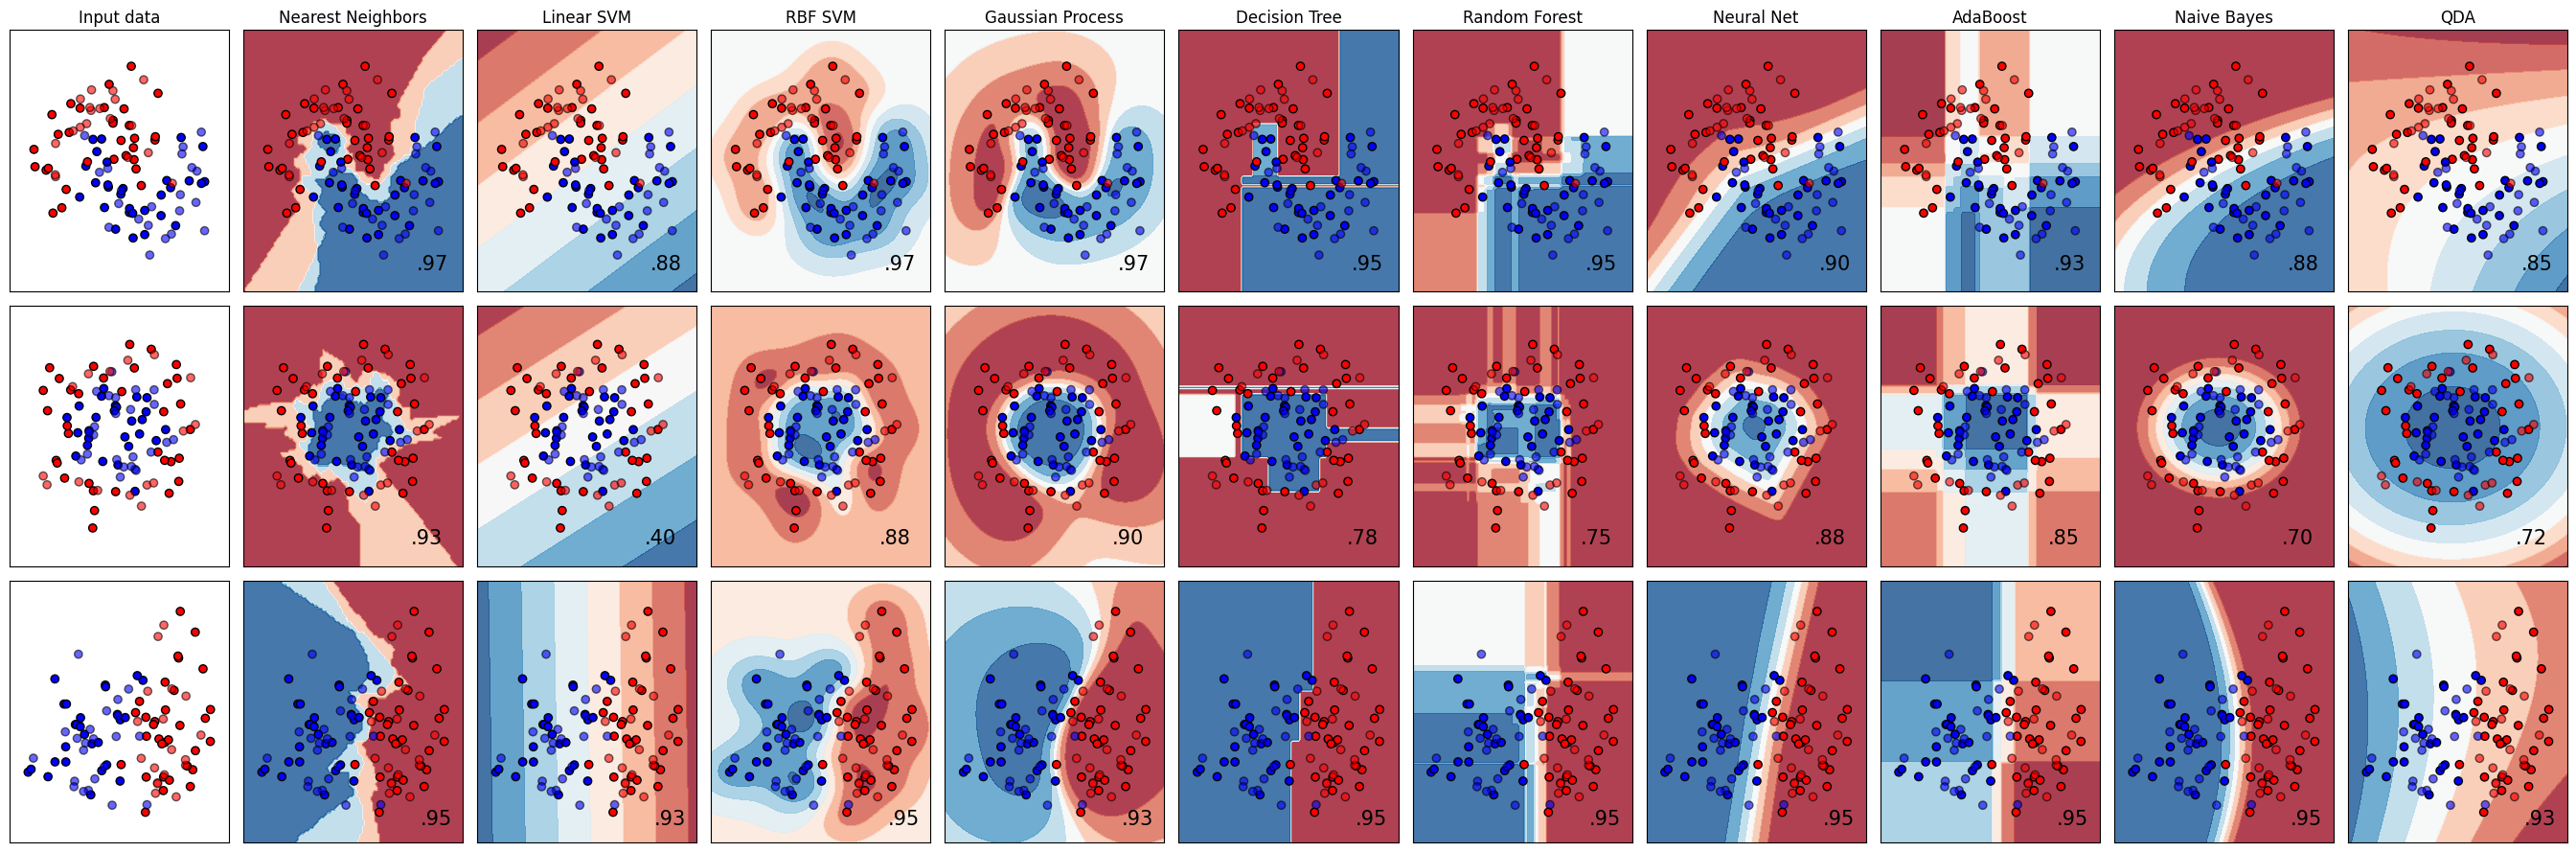

In [41]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause


from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, random_state=42),
    SVC(gamma=2, C=1, random_state=42),
    GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42),
    DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(
        max_depth=5, n_estimators=10, max_features=1, random_state=42
    ),
    MLPClassifier(alpha=1, max_iter=1000, random_state=42),
    AdaBoostClassifier(random_state=42),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]

X, y = make_classification(
    n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1
)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

datasets = [
    make_moons(noise=0.3, random_state=0),
    make_circles(noise=0.2, factor=0.5, random_state=1),
    linearly_separable,
]

figure = plt.figure(figsize=(27, 9))
i = 1
# iterate over datasets
for ds_cnt, ds in enumerate(datasets):
    # preprocess dataset, split into training and test part
    X, y = ds
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=42
    )

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # just plot the dataset first
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(["#FF0000", "#0000FF"])
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:
        ax.set_title("Input data")
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
    # Plot the testing points
    ax.scatter(
        X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k"
    )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i)

        clf = make_pipeline(StandardScaler(), clf)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)
        DecisionBoundaryDisplay.from_estimator(
            clf, X, cmap=cm, alpha=0.8, ax=ax, eps=0.5
        )

        # Plot the training points
        ax.scatter(
            X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k"
        )
        # Plot the testing points
        ax.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c=y_test,
            cmap=cm_bright,
            edgecolors="k",
            alpha=0.6,
        )

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:
            ax.set_title(name)
        ax.text(
            x_max - 0.3,
            y_min + 0.3,
            ("%.2f" % score).lstrip("0"),
            size=15,
            horizontalalignment="right",
        )
        i += 1

plt.tight_layout()
plt.show()